# Final Evaluation

This notebook performs the final evaluation of the selected XGBoost model for sepsis prediction.

The model was selected based on validation-set performance, with Precision-Recall AUC (PR-AUC) used as the primary evaluation metric because of the strong class imbalance in the dataset.

The classification threshold was selected using the validation set and is fixed at 0.80 for the final evaluation.

The test set is used only to report the final model performance.

The evaluation includes:

- PR-AUC
- ROC-AUC
- Precision
- Recall
- F1-score
- Accuracy
- Confusion matrix
- Precision-Recall curve
- ROC curve
- Classification report

This project is intended for educational and research purposes and is not a clinical diagnostic system.

___
___

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

## 2. Load Test Data and Saved Models

The processed test dataset and previously trained models are loaded for final evaluation.

The same final 10-feature set used during model comparison is retained.

In [2]:
# Load processed datasets
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1086991, 12)
Test shape: (309993, 12)


In [3]:
# Final feature set
final_features = [
    "Hemodynamic",
    "Respiratory",
    "Renal_Metabolic",
    "Inflammatory_Hematological",
    "Hepatic_Coagulation",
    "Hour",
    "ICULOS",
    "HospAdmTime",
    "Gender",
    "ICU_Unit"
]

target = "SepsisLabel"

X_test = test_df[final_features]
y_test = test_df[target]

print("Number of final features:", len(final_features))
print("Test feature shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Number of final features: 10
Test feature shape: (309993, 10)
Test target shape: (309993,)


In [4]:
# Load saved models
xgb_model = joblib.load("../models/xgboost_sepsis_model.pkl")
logistic_model = joblib.load("../models/logistic_regression_baseline.pkl")
rf_model = joblib.load("../models/random_forest_baseline.pkl")
hgb_model = joblib.load("../models/hist_gradient_boosting_baseline.pkl")
svm_model = joblib.load("../models/linear_svm_baseline.pkl")

print("All models loaded successfully.")

All models loaded successfully.


In [5]:
# Median imputation for baseline models
imputer = SimpleImputer(strategy="median")

X_train = train_df[final_features]

imputer.fit(X_train)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=final_features,
    index=X_test.index
)

print("Imputed test data shape:", X_test_imp.shape)

Imputed test data shape: (309993, 10)


## 3. Generate Final Test Predictions

The trained models are used to generate prediction scores on the held-out test set.

For XGBoost, the first 48 trees are used because iteration 47 produced the best validation PR-AUC during model evaluation.

The validation-selected classification thresholds are retained for final test evaluation.

In [6]:
final_thresholds = {
    "Logistic Regression": 0.75,
    "Random Forest": 0.80,
    "XGBoost": 0.80,
    "HistGradientBoosting": 0.80,
    "Linear SVM": 0.00
}

In [7]:
# Logistic Regression
logistic_test_scores = logistic_model.predict_proba(
    X_test_imp
)[:, 1]

# Random Forest
rf_test_scores = rf_model.predict_proba(
    X_test_imp
)[:, 1]

# XGBoost - use first 48 trees
xgb_test_scores = xgb_model.predict_proba(
    X_test,
    iteration_range=(0, 48)
)[:, 1]

# HistGradientBoosting
hgb_test_scores = hgb_model.predict_proba(
    X_test
)[:, 1]

# Linear SVM
svm_test_scores = svm_model.decision_function(
    X_test_imp
)

In [8]:
# Convert prediction scores into binary predictions

logistic_test_pred = (
    logistic_test_scores >= final_thresholds["Logistic Regression"]
).astype(int)

rf_test_pred = (
    rf_test_scores >= final_thresholds["Random Forest"]
).astype(int)

xgb_test_pred = (
    xgb_test_scores >= final_thresholds["XGBoost"]
).astype(int)

hgb_test_pred = (
    hgb_test_scores >= final_thresholds["HistGradientBoosting"]
).astype(int)

svm_test_pred = (
    svm_test_scores >= final_thresholds["Linear SVM"]
).astype(int)

In [9]:
print("Positive predictions:")
print("Logistic Regression:", logistic_test_pred.sum())
print("Random Forest:", rf_test_pred.sum())
print("XGBoost:", xgb_test_pred.sum())
print("HistGradientBoosting:", hgb_test_pred.sum())
print("Linear SVM:", svm_test_pred.sum())

Positive predictions:
Logistic Regression: 13320
Random Forest: 10810
XGBoost: 10748
HistGradientBoosting: 11249
Linear SVM: 70899


## 4. Final Test-Set Metrics

The final performance of each model is evaluated on the held-out test set using accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

PR-AUC is emphasized because the dataset is highly imbalanced.

In [10]:
def calculate_metrics(y_true, scores, predictions):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1-Score": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores)
    }

In [11]:
final_results = {
    "Logistic Regression": calculate_metrics(
        y_test,
        logistic_test_scores,
        logistic_test_pred
    ),

    "Random Forest": calculate_metrics(
        y_test,
        rf_test_scores,
        rf_test_pred
    ),

    "XGBoost": calculate_metrics(
        y_test,
        xgb_test_scores,
        xgb_test_pred
    ),

    "HistGradientBoosting": calculate_metrics(
        y_test,
        hgb_test_scores,
        hgb_test_pred
    ),

    "Linear SVM": calculate_metrics(
        y_test,
        svm_test_scores,
        svm_test_pred
    )
}

In [15]:
final_results_df = pd.DataFrame(final_results).T

In [16]:
final_results_df.round(6)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Logistic Regression,0.947205,0.106081,0.240634,0.147249,0.743265,0.073414
Random Forest,0.955896,0.139223,0.256301,0.180434,0.787584,0.091238
XGBoost,0.955805,0.135839,0.248638,0.175692,0.791266,0.092856
HistGradientBoosting,0.954060,0.128011,0.245232,0.168214,0.786422,0.088892
Linear SVM,0.775450,0.050508,0.609843,0.093290,0.744026,0.071523


## 5. Confusion Matrices

Confusion matrices are used to examine the number of true positives, true negatives, false positives, and false negatives produced by each model on the test set.

In [17]:
predictions = {
    "Logistic Regression": logistic_test_pred,
    "Random Forest": rf_test_pred,
    "XGBoost": xgb_test_pred,
    "HistGradientBoosting": hgb_test_pred,
    "Linear SVM": svm_test_pred
}

confusion_matrices = {}

for model_name, predictions_model in predictions.items():
    confusion_matrices[model_name] = confusion_matrix(
        y_test,
        predictions_model
    )

confusion_matrices

{'Logistic Regression': array([[292214,  11907],
        [  4459,   1413]]),
 'Random Forest': array([[294816,   9305],
        [  4367,   1505]]),
 'XGBoost': array([[294833,   9288],
        [  4412,   1460]]),
 'HistGradientBoosting': array([[294312,   9809],
        [  4432,   1440]]),
 'Linear SVM': array([[236803,  67318],
        [  2291,   3581]])}

In [18]:
for model_name, cm in confusion_matrices.items():
    print(f"\n{model_name}")
    print(cm)


Logistic Regression
[[292214  11907]
 [  4459   1413]]

Random Forest
[[294816   9305]
 [  4367   1505]]

XGBoost
[[294833   9288]
 [  4412   1460]]

HistGradientBoosting
[[294312   9809]
 [  4432   1440]]

Linear SVM
[[236803  67318]
 [  2291   3581]]


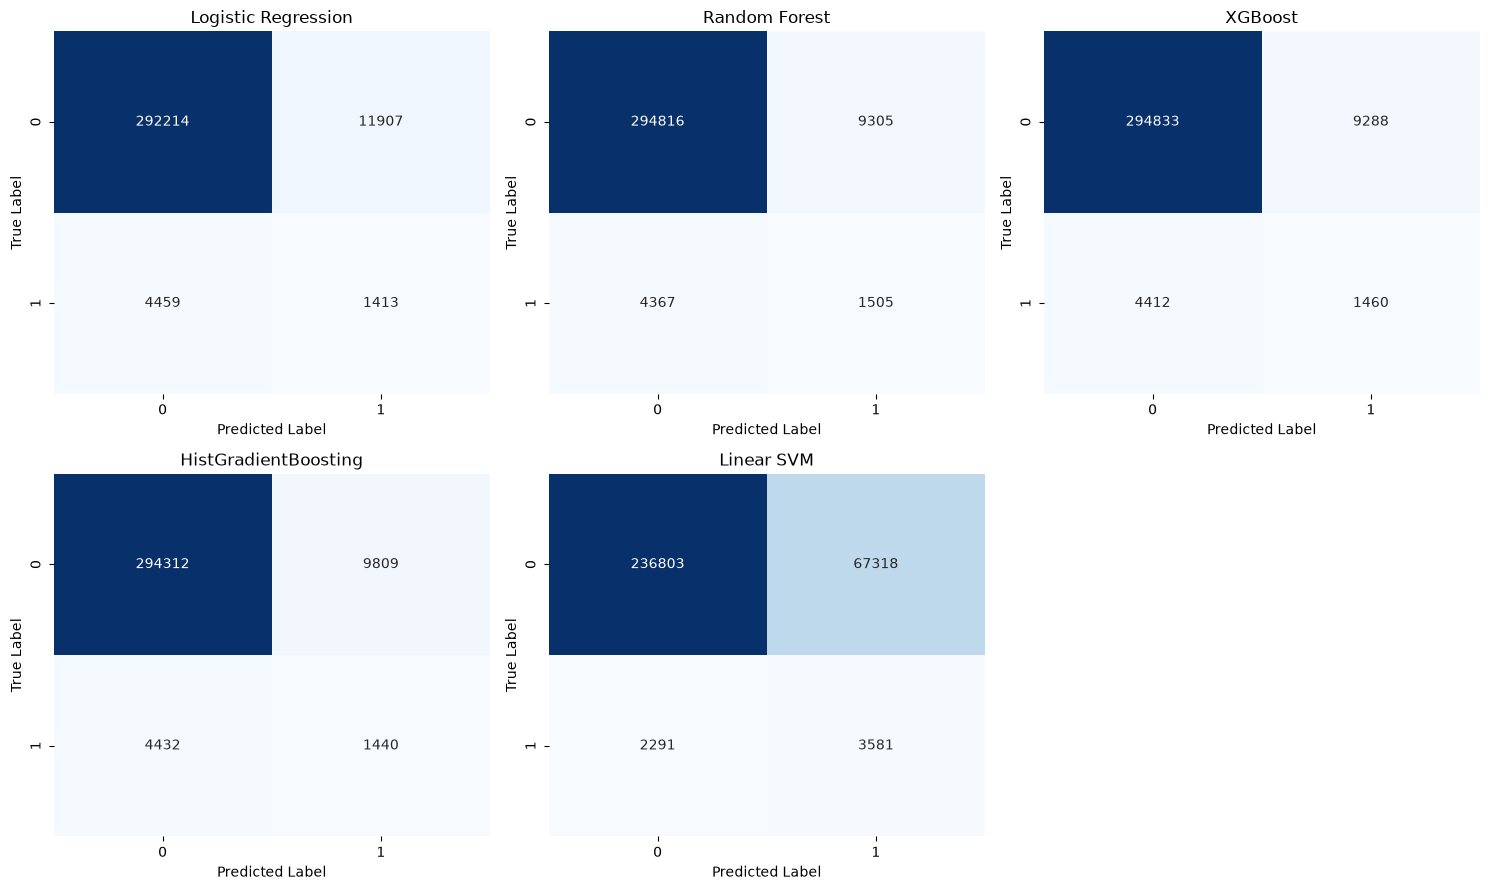

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (model_name, cm) in zip(
    axes.ravel(),
    confusion_matrices.items()
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

# Hide unused subplot
axes.ravel()[-1].axis("off")

plt.tight_layout()
plt.show()

## 6. Precision-Recall Curves

Precision-Recall curves show the trade-off between precision and recall across different classification thresholds.

PR-AUC is particularly useful for this project because the sepsis class is highly imbalanced.

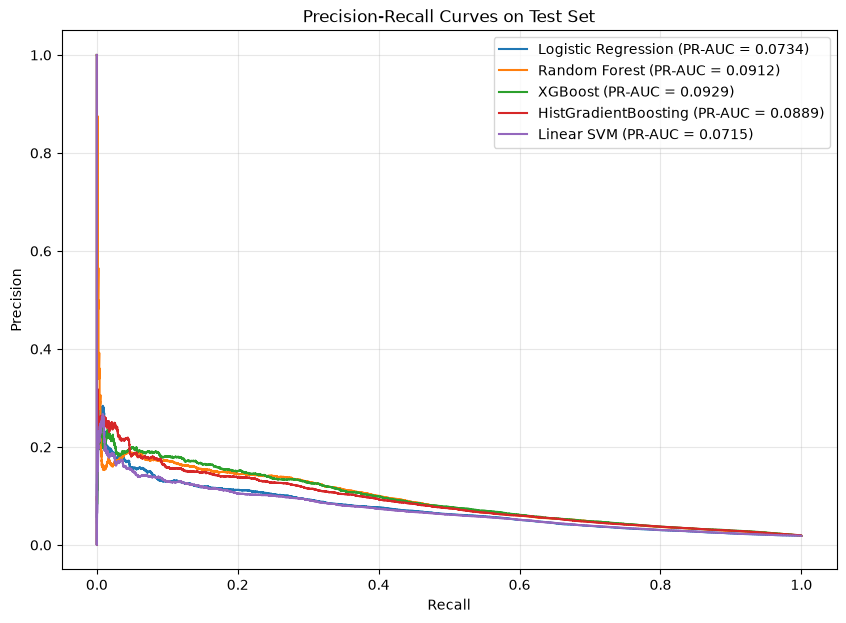

In [20]:
model_scores = {
    "Logistic Regression": logistic_test_scores,
    "Random Forest": rf_test_scores,
    "XGBoost": xgb_test_scores,
    "HistGradientBoosting": hgb_test_scores,
    "Linear SVM": svm_test_scores
}

plt.figure(figsize=(10, 7))

for model_name, scores in model_scores.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        scores
    )

    pr_auc = average_precision_score(
        y_test,
        scores
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (PR-AUC = {pr_auc:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves on Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 7. ROC Curves

ROC curves show the relationship between the true positive rate and false positive rate across different classification thresholds.

ROC-AUC provides a threshold-independent measure of the model's ability to distinguish between the two classes.

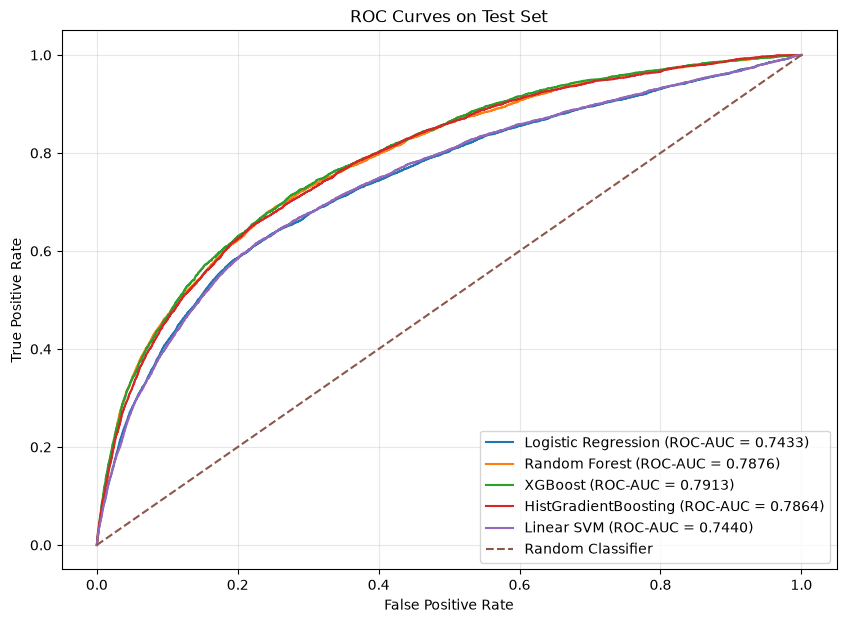

In [21]:
plt.figure(figsize=(10, 7))

for model_name, scores in model_scores.items():
    fpr, tpr, _ = roc_curve(
        y_test,
        scores
    )

    roc_auc = roc_auc_score(
        y_test,
        scores
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (ROC-AUC = {roc_auc:.4f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 8. Classification Reports

Classification reports provide class-level precision, recall, and F1-score for each model on the held-out test set.

In [22]:
for model_name, predictions_model in predictions.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions_model,
            target_names=["Non-Sepsis", "Sepsis"],
            digits=4,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

  Non-Sepsis     0.9850    0.9608    0.9728    304121
      Sepsis     0.1061    0.2406    0.1472      5872

    accuracy                         0.9472    309993
   macro avg     0.5455    0.6007    0.5600    309993
weighted avg     0.9683    0.9472    0.9571    309993

Random Forest
              precision    recall  f1-score   support

  Non-Sepsis     0.9854    0.9694    0.9773    304121
      Sepsis     0.1392    0.2563    0.1804      5872

    accuracy                         0.9559    309993
   macro avg     0.5623    0.6129    0.5789    309993
weighted avg     0.9694    0.9559    0.9622    309993

XGBoost
              precision    recall  f1-score   support

  Non-Sepsis     0.9853    0.9695    0.9773    304121
      Sepsis     0.1358    0.2486    0.1757      5872

    accuracy                         0.9558    309993
   macro avg     0.5605    0.6090    0.5765    309993
weighted avg     0.9692    0.955

In [23]:
classification_summary = []

for model_name, predictions_model in predictions.items():

    report = classification_report(
        y_test,
        predictions_model,
        target_names=["Non-Sepsis", "Sepsis"],
        output_dict=True,
        zero_division=0
    )

    classification_summary.append({
        "Model": model_name,
        "Sepsis Precision": report["Sepsis"]["precision"],
        "Sepsis Recall": report["Sepsis"]["recall"],
        "Sepsis F1-Score": report["Sepsis"]["f1-score"]
    })

classification_summary_df = pd.DataFrame(classification_summary)

classification_summary_df.round(6)

,Model,Sepsis Precision,Sepsis Recall,Sepsis F1-Score
0,Logistic Regression,0.106081,0.240634,0.147249
1,Random Forest,0.139223,0.256301,0.180434
2,XGBoost,0.135839,0.248638,0.175692
3,HistGradientBoosting,0.128011,0.245232,0.168214
4,Linear SVM,0.050508,0.609843,0.093290


## 9. Final XGBoost Evaluation

Based on the validation-set model comparison, XGBoost was selected as the final candidate model.

The final evaluation is performed on the held-out test set using:

- the XGBoost model saved during modeling,
- the first 48 trees corresponding to the best validation PR-AUC,
- the classification threshold of 0.80 selected using the validation set.

The test set is used only to report the final performance of the selected model.

In [27]:
# Final XGBoost test scores
final_xgb_scores = xgb_model.predict_proba(
    X_test,
    iteration_range=(0, 48)
)[:, 1]

# Final classification threshold
final_xgb_threshold = 0.80

# Final binary predictions
final_xgb_predictions = (
    final_xgb_scores >= final_xgb_threshold
).astype(int)

print("Number of test observations:", len(y_test))
print("Positive predictions:", final_xgb_predictions.sum())
print("Actual positive cases:", y_test.sum())

Number of test observations: 309993
Positive predictions: 10748
Actual positive cases: 5872


In [28]:
final_xgb_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        final_xgb_predictions
    ),
    "Precision": precision_score(
        y_test,
        final_xgb_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        final_xgb_predictions,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        final_xgb_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        final_xgb_scores
    ),
    "PR-AUC": average_precision_score(
        y_test,
        final_xgb_scores
    )
}

final_xgb_metrics

{'Accuracy': 0.9558054536715345,
 'Precision': 0.13583922590249348,
 'Recall': 0.24863760217983652,
 'F1-Score': 0.17569193742478942,
 'ROC-AUC': 0.7912656663138714,
 'PR-AUC': 0.0928557996528471}

In [29]:
final_xgb_results = pd.DataFrame(
    [final_xgb_metrics],
    index=["XGBoost"]
)

final_xgb_results.round(6)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
XGBoost,0.955805,0.135839,0.248638,0.175692,0.791266,0.092856


## 10. Final XGBoost Confusion Matrix

The confusion matrix shows how the final XGBoost model classified the held-out test observations at the validation-selected threshold of 0.80.

In [30]:
# Calculate confusion matrix
final_xgb_cm = confusion_matrix(
    y_test,
    final_xgb_predictions
)

print("XGBoost Confusion Matrix:")
print(final_xgb_cm)

XGBoost Confusion Matrix:
[[294833   9288]
 [  4412   1460]]


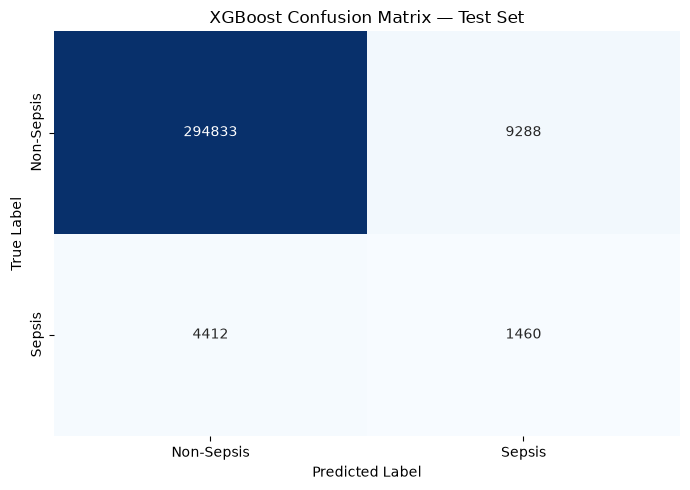

In [31]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    final_xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Non-Sepsis", "Sepsis"],
    yticklabels=["Non-Sepsis", "Sepsis"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix — Test Set")

plt.tight_layout()
plt.show()

## 11. Final XGBoost Precision-Recall Curve

The Precision-Recall curve evaluates the trade-off between precision and recall across different classification thresholds.

PR-AUC is particularly important for this project because the sepsis class is highly imbalanced.

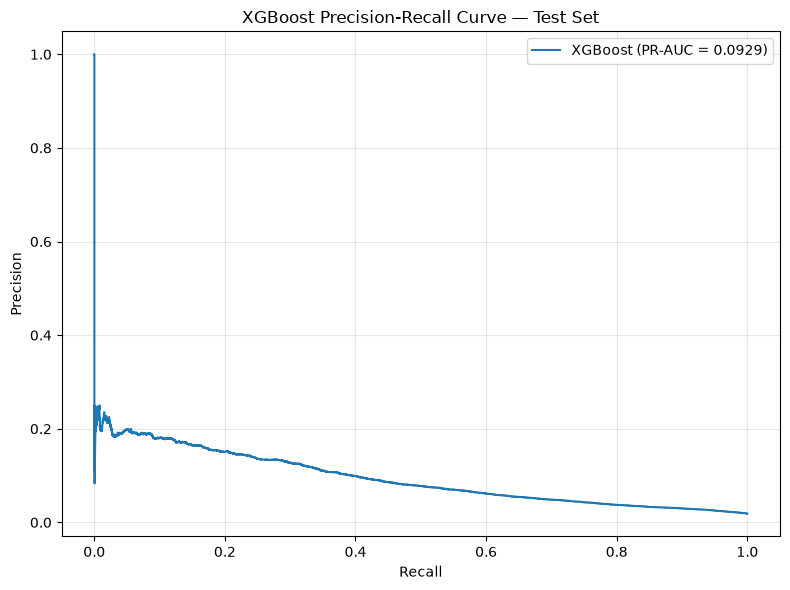

In [32]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    final_xgb_scores
)

final_pr_auc = average_precision_score(
    y_test,
    final_xgb_scores
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (PR-AUC = {final_pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve — Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

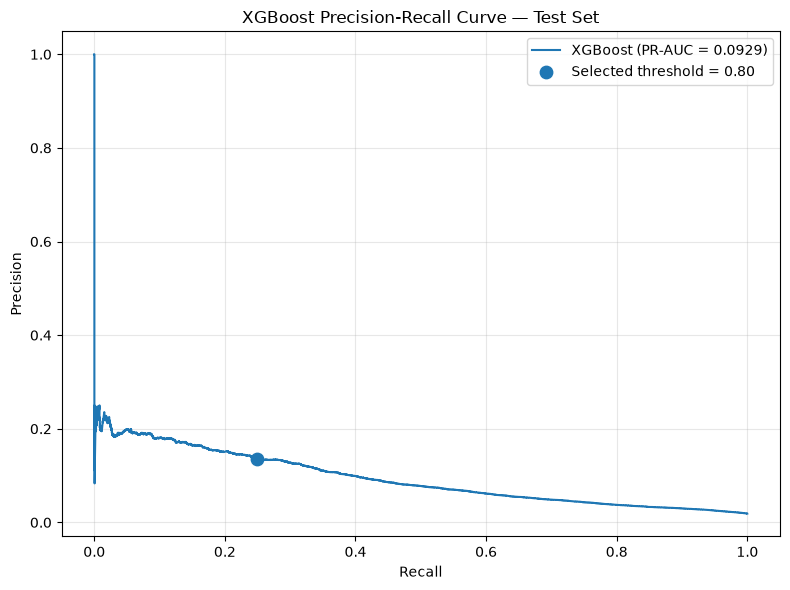

In [33]:
threshold = 0.80

threshold_predictions = (
    final_xgb_scores >= threshold
).astype(int)

threshold_precision = precision_score(
    y_test,
    threshold_predictions,
    zero_division=0
)

threshold_recall = recall_score(
    y_test,
    threshold_predictions,
    zero_division=0
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (PR-AUC = {final_pr_auc:.4f})"
)

plt.scatter(
    threshold_recall,
    threshold_precision,
    s=80,
    label="Selected threshold = 0.80"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve — Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Final XGBoost ROC Curve

The ROC curve shows the relationship between the true positive rate and false positive rate across different classification thresholds.

ROC-AUC provides a threshold-independent measure of the model's ability to distinguish between sepsis and non-sepsis observations.

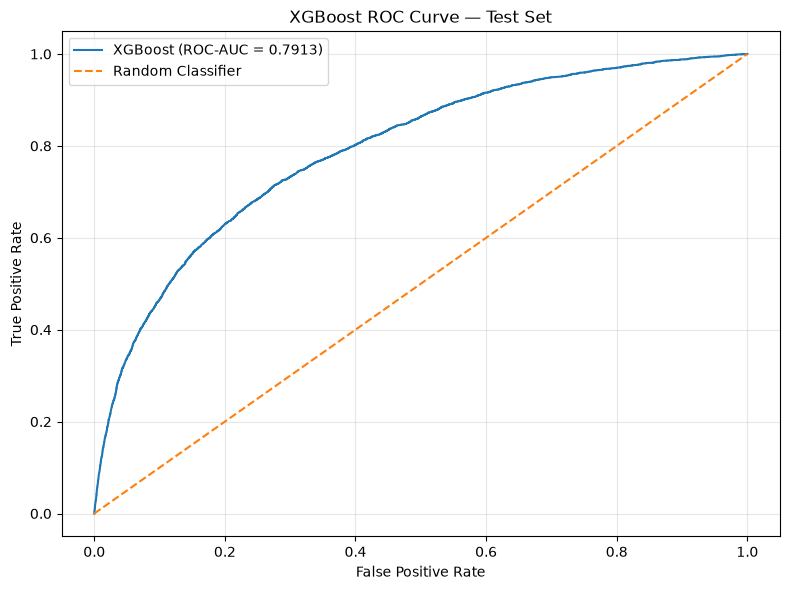

In [35]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    final_xgb_scores
)

final_roc_auc = roc_auc_score(
    y_test,
    final_xgb_scores
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (ROC-AUC = {final_roc_auc:.4f})"
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve — Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

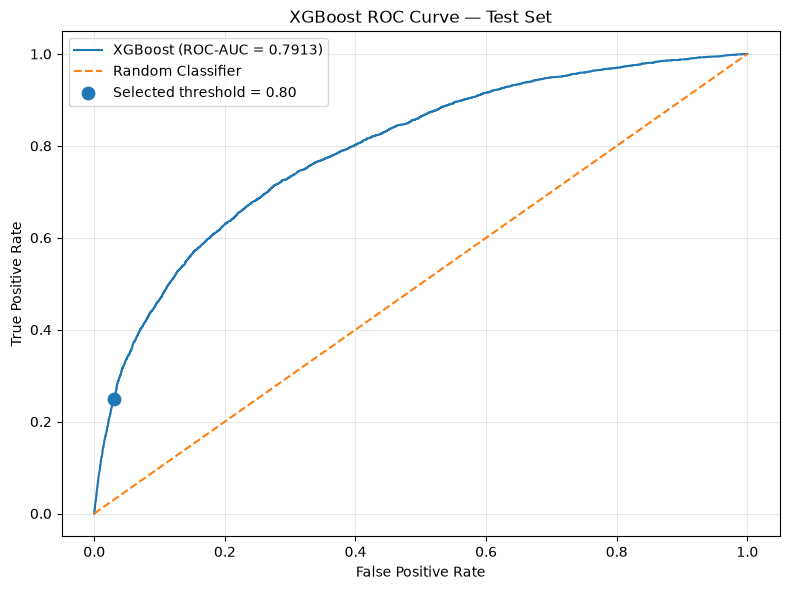

In [36]:
selected_threshold = 0.80

selected_predictions = (
    final_xgb_scores >= selected_threshold
).astype(int)

selected_cm = confusion_matrix(
    y_test,
    selected_predictions
)

tn, fp, fn, tp = selected_cm.ravel()

selected_tpr = tp / (tp + fn)
selected_fpr = fp / (fp + tn)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (ROC-AUC = {final_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.scatter(
    selected_fpr,
    selected_tpr,
    s=80,
    label="Selected threshold = 0.80"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve — Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Final XGBoost Classification Report

The classification report provides the precision, recall, and F1-score for the non-sepsis and sepsis classes on the held-out test set using the final classification threshold of 0.80.

In [37]:
final_xgb_report = classification_report(
    y_test,
    final_xgb_predictions,
    target_names=["Non-Sepsis", "Sepsis"],
    digits=6,
    zero_division=0
)

print(final_xgb_report)

              precision    recall  f1-score   support

  Non-Sepsis   0.985256  0.969460  0.977294    304121
      Sepsis   0.135839  0.248638  0.175692      5872

    accuracy                       0.955805    309993
   macro avg   0.560548  0.609049  0.576493    309993
weighted avg   0.969166  0.955805  0.962110    309993



In [40]:
with open(
    "../results/xgboost_classification_report.csv",
    "w"
) as file:
    file.write(final_xgb_report)

print("Classification report saved successfully.")

Classification report saved successfully.


## 14. Final XGBoost Feature Importance

Feature importance is examined to understand which features contributed most to the final XGBoost model.

The built-in XGBoost feature importance is based on the model's tree structure and provides an overall measure of feature contribution.

In [41]:
feature_importance = pd.DataFrame({
    "Feature": final_features,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,ICULOS,0.307867
1,Respiratory,0.134945
2,Hour,0.107581
3,ICU_Unit,0.079999
4,HospAdmTime,0.077891
5,Renal_Metabolic,0.066904
6,Gender,0.062616
7,Inflammatory_Hematological,0.061797
8,Hepatic_Coagulation,0.053556
9,Hemodynamic,0.046843


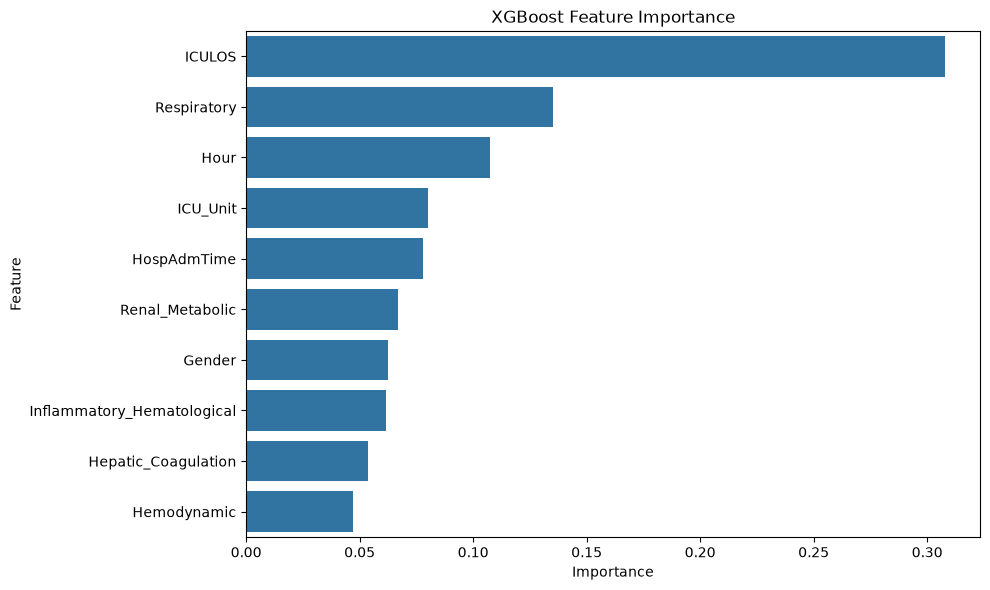

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

___
___

## Final Interpretation

The final XGBoost model was evaluated on the held-out test set after model selection and threshold selection were performed using the validation set.

Using the first 48 trees and a classification threshold of 0.80, the model achieved:

- Accuracy: 0.955805
- Precision: 0.135839
- Recall: 0.248638
- F1-Score: 0.175692
- ROC-AUC: 0.791266
- PR-AUC: 0.092856

The ROC-AUC indicates that the model has useful discrimination between sepsis and non-sepsis observations. The PR-AUC provides a more informative assessment for this highly imbalanced dataset.

At the selected threshold, the model identified 1,460 of the 5,872 positive test observations, while producing 9,288 false positive predictions. This demonstrates the trade-off between precision and recall in an imbalanced prediction problem.

Feature importance analysis showed that ICULOS was the most influential individual feature, followed by Respiratory and Hour. Temporal variables collectively contributed substantially to the model's predictions.

These feature importance results describe how the trained model uses the available variables and should not be interpreted as evidence of clinical causality.

___
___

##  Limitations

Several limitations should be considered when interpreting the results:

1. The dataset is highly imbalanced, with substantially fewer sepsis observations than non-sepsis observations.

2. The data contains substantial missingness, particularly among laboratory measurements.

3. The clinical reference ranges used during feature engineering were heuristic project-level assumptions and were not validated as clinical decision thresholds.

4. The domain scores and feature weighting strategy were designed for this educational research project and should not be interpreted as validated clinical scores.

5. The model uses temporal variables such as Hour and ICULOS, which may capture patterns related to ICU length of stay and data collection processes.

6. The dataset is derived from the PhysioNet/CinC 2019 sepsis prediction challenge and therefore may not represent all hospitals or patient populations.

7. Model performance on this dataset does not establish clinical effectiveness or generalizability to other healthcare settings.

8. The model has not undergone prospective clinical validation.

9. The final XGBoost model should therefore be considered an educational and research model rather than a clinical diagnostic or decision-support system.

___
___

## Conclusion

This project developed an end-to-end machine learning workflow for sepsis prediction, including exploratory data analysis, patient-level data splitting, missing-value handling, clinical domain feature engineering, dimensionality reduction, XGBoost modeling, baseline model comparison, and final evaluation.

Five models were evaluated during model comparison. XGBoost was selected as the final candidate based on its validation PR-AUC.

The final XGBoost evaluation on the held-out test set achieved a PR-AUC of 0.092856 and ROC-AUC of 0.791266, with an F1-score of 0.175692 at the validation-selected threshold of 0.80.

The results demonstrate the challenges of predicting a rare clinical outcome from highly incomplete longitudinal ICU data and highlight the importance of patient-level splitting, appropriate evaluation metrics, threshold selection, and careful interpretation of model outputs.

The project is intended for educational and research purposes and should not be interpreted as a clinical diagnostic system.

___
___